In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')
from spectraformer.input_pipeline import preprocess_dataset, batch_sampler
import spectraformer.baselines
from spectraformer.model import SpectraFormer
import xarray as xr
import flax.linen as nn
import optax
import matplotlib.pyplot as plt
import numpy as np

### Dataset loading

In [4]:
data = xr.load_dataarray('/home/dpoteryayev/SpectraFormer/data/SiC_19x10x3.nc')
spatial_dims = data.dims[:-1]
filtered_data = data.stack(spectra=spatial_dims).dropna(
    dim="spectra"
)
full_spectra = np.asarray(filtered_data.values)
wave_number = np.asarray(filtered_data.wave_number.values)

In [5]:
bg_mask = np.logical_and(wave_number > 2200, wave_number < 2500)

In [6]:
offset = np.median(full_spectra[bg_mask], axis=0)
full_spectra -= offset

full_spectra /= np.max(full_spectra, axis=0)
median_spectra = np.median(full_spectra, axis=1)

sup_norm_deviations = (abs(full_spectra - median_spectra[:, None])).max(axis=0)
cleaned_spectra = full_spectra[:, ~(sup_norm_deviations > 0.15)]

step_mask = np.logical_and(wave_number > 1800, wave_number < 1850)
cleaned_spectra /= cleaned_spectra[step_mask,:].mean(axis=0)

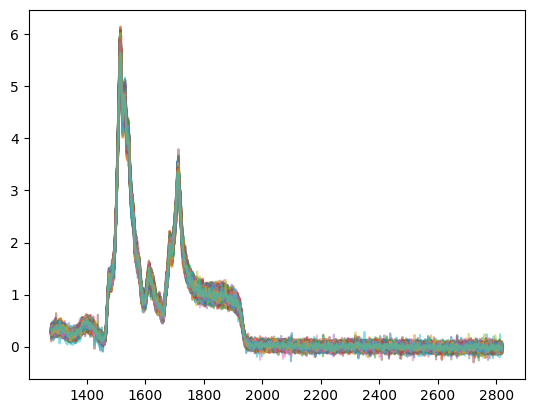

In [7]:
plt.plot(wave_number, cleaned_spectra, alpha=0.5);
#plt.plot(wave_number, median_spectra, 'k-', alpha=0.5);

In [8]:
import ml_confs
from pathlib import Path

model_tag = "min"  # Can be ["min","base"] -    # CHOOSE ONE FROM THE LIST (.yaml file should exist)
                                                # tag also can be found for already trained models in checkpoints folder

maindir = Path('inspect_results.ipynb').parent.resolve()
configs_folder = maindir / "configs"
config_file_name = f"configs_{model_tag}.yaml"
config_file_path = configs_folder / config_file_name

configs = ml_confs.from_file(config_file_path)
configs.tabulate()

train_ds = preprocess_dataset(xr.load_dataarray('data/SiC_19x10x3.nc'))
test_ds = preprocess_dataset(xr.load_dataarray('data/SiC+Graphene_50x20.nc'))
mask_windows=list(
        zip(configs.masked_interval_starts, configs.masked_interval_ends)
    )
dummy_example = next(batch_sampler(train_ds, batch_size=1, mask_windows=mask_windows))
print("Data batch shapes:")
for k, v in dummy_example.items():
    print(f"  {k} -> {v.shape}")

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Key                    ┃ Value             ┃ Type      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ tag                    │ spectraformer:min │ str       │
│ embedding_dim          │ 64                │ int       │
│ num_heads              │ 8                 │ int       │
│ num_layers             │ 2                 │ int       │
│ learning_rate          │ 0.0001            │ float     │
│ num_epochs             │ 100               │ int       │
│ batch_size             │ 19                │ int       │
│ dropout_rate           │ 0.5               │ float     │
│ root_rng_seed          │ 0                 │ int       │
│ train_dataset          │ SiC_19x10x3       │ str       │
│ log_every_epochs       │ 5                 │ int       │
│ masked_interval_starts │ [1000, 2500]      │ list[int] │
│ masked_interval_ends   │ [1700, 2900]      │ list[int] │
└────────────────────────┴───────────────────┴───────────┘

Data batch shapes:
  spectra -> (1, 1015, 1)
  masked_spectra -> (1, 1015, 1)
  wave_number -> (1015, 1)
  mask -> (1015,)


### Model loading

In [11]:
from spectraformer.inference import predict, plot_results
import orbax.checkpoint as ocp
checkpointer = ocp.StandardCheckpointer()
ckpt_dir = "/home/dpoteryayev/SpectraFormer/checkpoints/"
test_batch = next(batch_sampler(test_ds, batch_size=1, mask_windows=mask_windows))

In [ ]:
median_baseline_variables = checkpointer.restore(ckpt_dir + 'baselines:median/100x10/')
baseline_predictions = predict(spectraformer.baselines.median, median_baseline_variables, test_batch)
for k, v in baseline_predictions.items():
    print(f"  {k} -> {v.shape}")

In [ ]:
fig, ax = plot_results(baseline_predictions)
ax.set_title('Median Baseline')

In [12]:
model_tag = 'spectraformer:min'
ckpt_manager = ocp.CheckpointManager(
        ckpt_dir + model_tag,
        item_handlers=ocp.StandardCheckpointHandler(),
    )

In [13]:
import ml_confs
from flax.training.train_state import TrainState

configs = ml_confs.from_dict(ckpt_manager.metadata())

# Re-initialize model based on loaded configs
model = SpectraFormer(
    num_heads=configs.num_heads,
    num_layers=configs.num_layers,
    embedding_dim=configs.embedding_dim,
)

# RNG Keys
root_key = jax.random.key(seed=configs.root_rng_seed)
main_key, params_key, dropout_key = jax.random.split(key=root_key, num=3)

# Model Initialization
variables = model.init(
    params_key,
    dummy_example["masked_spectra"][0],
    dummy_example["wave_number"],
    dummy_example["mask"],
    training=False,
)

state = TrainState.create(
    apply_fn=jax.jit(
        model.apply, static_argnames=("training", "capture_intermediates")
    ),
    params=variables["params"],
    tx=optax.adam(configs.learning_rate),
)
# Restore checkpoint
state = ckpt_manager.restore(
    ckpt_manager.latest_step(), args=ocp.args.StandardRestore(state)
)

In [14]:
tabulate_fn = nn.tabulate(model, jax.random.key(0), depth = 1, console_kwargs={'force_jupyter': True})
print(tabulate_fn(dummy_example['masked_spectra'][0], dummy_example['wave_number'], dummy_example['mask'], training = False))

                                               SpectraFormer Summary                                               
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ path                  ┃ module                ┃ inputs                ┃ outputs          ┃ params               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│                       │ SpectraFormer         │ - float32[1015,1]     │ float32[1015,1]  │                      │
│                       │                       │ - float32[1015,1]     │                  │                      │
│                       │                       │ - bool[1015]          │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ LinearProjection_0    │ LinearProjection      │ float32[1015,1]       │ float32[1015,64] │ 128 (512 B)          │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ LinearProjection_1    │ LinearProjection      │ float32[1015,1]       │ float32[1015,64] │ 128 (512 B)          │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,64]    │ float32[1015,64] │ 58,304 (233.2 KB)    │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,64]    │ float32[1015,64] │ 58,304 (233.2 KB)    │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ LayerNorm_0           │ LayerNorm             │ float32[1015,64]      │ float32[1015,64] │ bias: float32[64]    │
│                       │                       │                       │                  │ scale: float32[64]   │
│                       │                       │                       │                  │                      │
│                       │                       │                       │                  │ 128 (512 B)          │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ Dense_0               │ Dense                 │ float32[1015,64]      │ float32[1015,1]  │ bias: float32[1]     │
│                       │                       │                       │                  │ kernel:              │
│                       │                       │                       │                  │ float32[64,1]        │
│                       │                       │                       │                  │                      │
│                       │                       │                       │                  │ 65 (260 B)           │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│                       │                       │       

In [15]:
spectraformer_predictions = predict(state.apply_fn, {'params': state.params}, test_batch, test_batch['mask'])
for k, v in spectraformer_predictions.items():
    print(f"  {k} -> {v.shape}")

  spectra -> (1015,)
  masked_spectra -> (1015,)
  wave_number -> (1015,)
  mask -> (1015,)
  predicted_spectra -> (1015,)
  predicted_difference -> (1015,)


Text(0.5, 1.0, 'Spectraformer spectraformer:min')

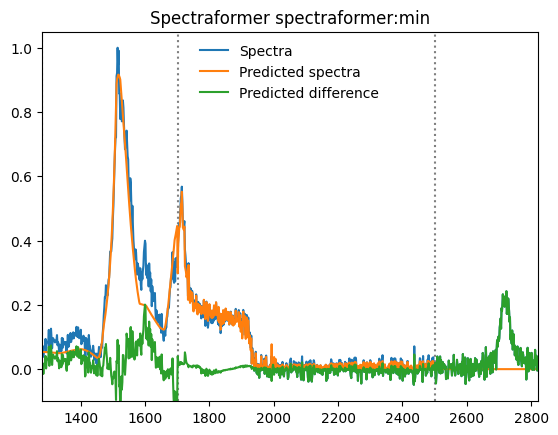

In [16]:
fig, ax = plot_results(spectraformer_predictions)
ax.set_title(f'Spectraformer {model_tag}')